In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("email_classification_dataset.csv")

In [3]:
data.head()

,id,email,label
0,2685,From: support@legitcompany.com\nSubject: Regar...,ham
1,5857,From: noreply@softwareupdates.com\nSubject: We...,ham
2,2399,From: noreply@softwareupdates.com\nSubject: Im...,ham
3,3244,From: info@customerservice.co\nSubject: Team S...,ham
4,2844,From: info@customerservice.co\nSubject: Team S...,ham


# STEP : 02 DATA CLEANING

In [4]:
data.head(10)

,id,email,label
0,2685,From: support@legitcompany.com\nSubject: Regar...,ham
1,5857,From: noreply@softwareupdates.com\nSubject: We...,ham
2,2399,From: noreply@softwareupdates.com\nSubject: Im...,ham
3,3244,From: info@customerservice.co\nSubject: Team S...,ham
4,2844,From: info@customerservice.co\nSubject: Team S...,ham
5,9740,From: survey@retailfeedback.com\nSubject: Invo...,ham
6,9126,From: info@customerservice.co\nSubject: Invoic...,ham
7,5188,From: noreply@softwareupdates.com\nSubject: Fe...,ham
8,9823,From: survey@retailfeedback.com\nSubject: Your...,ham
9,3726,From: family@homemail.net\nSubject: Important:...,ham


In [5]:
data.isnull()

,id,email,label
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
9995,False,False,False
9996,False,False,False
9997,False,False,False
9998,False,False,False


In [7]:
data.isnull().sum()

id       0
email    0
label    0
dtype: int64

In [9]:
data.shape


(10000, 3)

<Axes: >

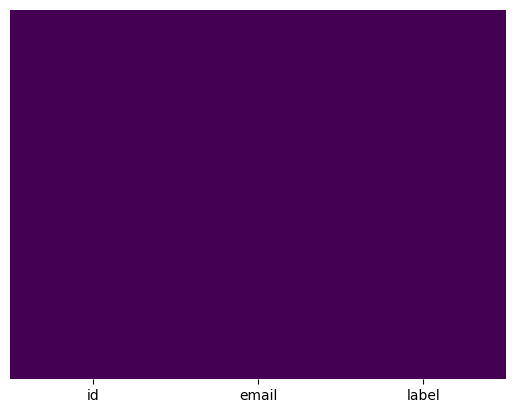

In [11]:
sns.heatmap(data.isnull(),yticklabels=False,cbar=False,cmap='viridis')

 # Data is fully clean

# STEP :03 VISUILIZING DATA

C:\Users\Zaid Khan\AppData\Local\Temp\ipykernel_12088\472063581.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label',data=data,palette='RdBu_r')


<Axes: xlabel='label', ylabel='count'>

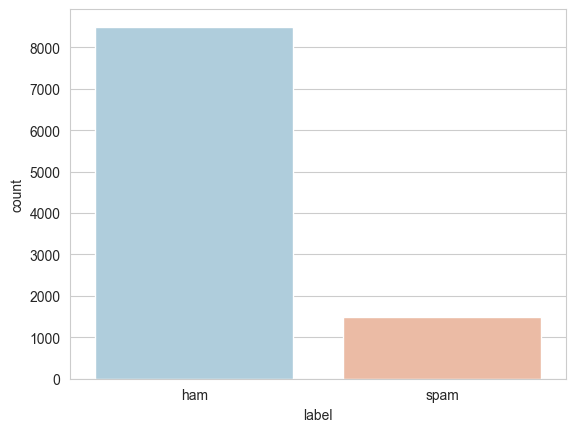

In [19]:
sns.set_style('whitegrid')
sns.countplot(x='label',data=data,palette='RdBu_r')


<Axes: xlabel='label', ylabel='count'>

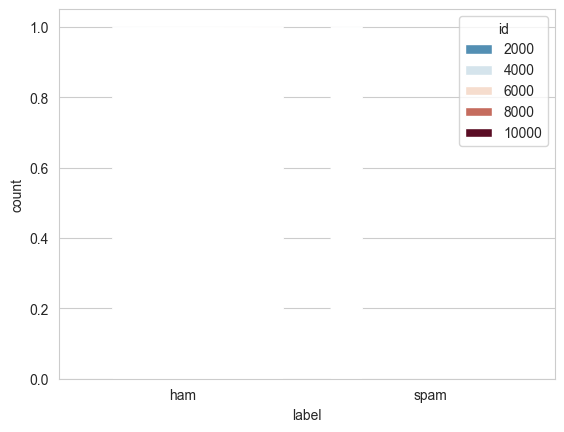

In [35]:
sns.set_style('whitegrid')
sns.countplot(x='label',hue='id',data=data,palette='RdBu_r')


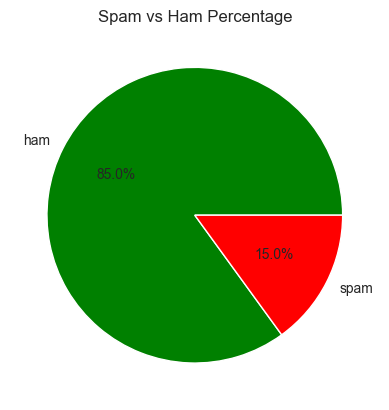

In [34]:
data['label'].value_counts().plot(kind='pie', 
                                autopct='%1.1f%%', 
                                colors=['green','red'])
plt.title('Spam vs Ham Percentage')
plt.show()

In [33]:
data['label'].value_counts()

label
ham     8500
spam    1500
Name: count, dtype: int64

# STEP :05 SPLIT DATA INTO X-TRAIN , Y-TARIN, X-TEST, Y-TEST

In [32]:
from sklearn.model_selection import train_test_split

In [36]:
# X = data.drop('label',axis=1)
X = data['email'] 
# Y = data['label']
Y = data['label']  


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    Y, test_size=0.30,
                                                    random_state=101)

# STEP 06 TRAINING MODEL and coverting text(email)into O/1

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer

In [39]:
vectorizer = CountVectorizer()

In [40]:
logmodel = LogisticRegression()

In [41]:
# Convert X_train text to numbers
X_train_counts = vectorizer.fit_transform(X_train)

In [42]:
X_test_counts = vectorizer.transform(X_test)

In [43]:
# conversion of ham and spam into 0/1
data['label_num'] = data['label'].map({'ham': 0, 'spam': 1})
#
## Simple Flow:
#```
#label column       label_num column
#"ham"    →  map()  →      0
#"spam"   →  map()  →      1


In [44]:
data.columns

Index(['id', 'email', 'label', 'label_num'], dtype='str')

In [45]:
logmodel.fit(X_train_counts, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# STEP 7 PREDICITIONS

In [46]:
predictions = logmodel.predict(X_test_counts)  # ✅ Converted numbers present into [0,1,,1,0,0,0,1]

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# STEP 8 FINDING ACCURACY AND CONFUSTION MATRIX

In [49]:
cm=confusion_matrix(y_test,predictions)

In [50]:
cm

array([[2551,    0],
       [   0,  449]])

In [51]:
from sklearn.metrics import accuracy_score

In [52]:
accuracy=accuracy_score(y_test,predictions)

In [53]:
accuracy

1.0

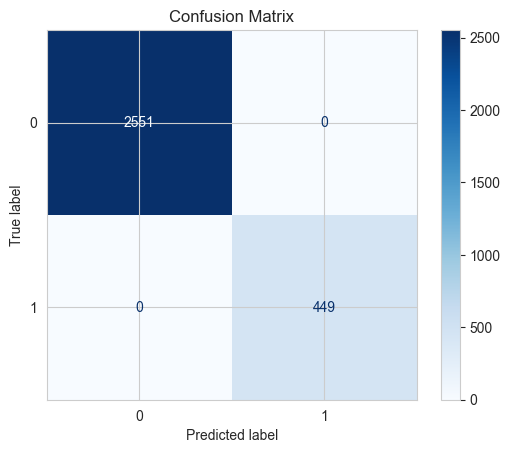

In [54]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()